# 🚀 Team 2: SVM Model Development
## Currency Exchange Movement Prediction

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.pipeline import Pipeline
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load Team 1's processed data
data = pd.read_csv('../data/processed/processed_data.csv')

# Display basic information
print(f"📊 Data Shape: {data.shape}")
print("\n📋 First 5 rows:")
print(data.head())

print("\n📋 Data Types:")
print(data.dtypes)

print("\n📊 Basic Statistics:")
print(data.describe())

print("\n🔍 Check for Missing Values:")
print(data.isnull().sum())

📊 Data Shape: (6679, 7)

📋 First 5 rows:
    lag_1   lag_2   lag_3  return_1d     ma_5    ma_10  target
0  112.65  111.76  112.74  -0.000799  112.370  111.654       0
1  112.56  112.65  111.76  -0.003643  112.372  111.893       1
2  112.15  112.56  112.65   0.003388  112.330  112.055       0
3  112.53  112.15  112.56  -0.000444  112.474  112.213       0
4  112.48  112.53  112.15  -0.006668  112.290  112.220       1

📋 Data Types:
lag_1        float64
lag_2        float64
lag_3        float64
return_1d    float64
ma_5         float64
ma_10        float64
target         int64
dtype: object

📊 Basic Statistics:
             lag_1        lag_2        lag_3    return_1d         ma_5  \
count  6679.000000  6679.000000  6679.000000  6679.000000  6679.000000   
mean    111.575738   111.569146   111.562543     0.000063   111.569119   
std      20.598437    20.591329    20.583881     0.005429    20.584145   
min      75.760000    75.760000    75.760000    -0.037250    75.888000   
25%      99.47

📊 Target Distribution:
Class 0 (Down/Same): 3369 (50.4%)
Class 1 (Up): 3310 (49.6%)


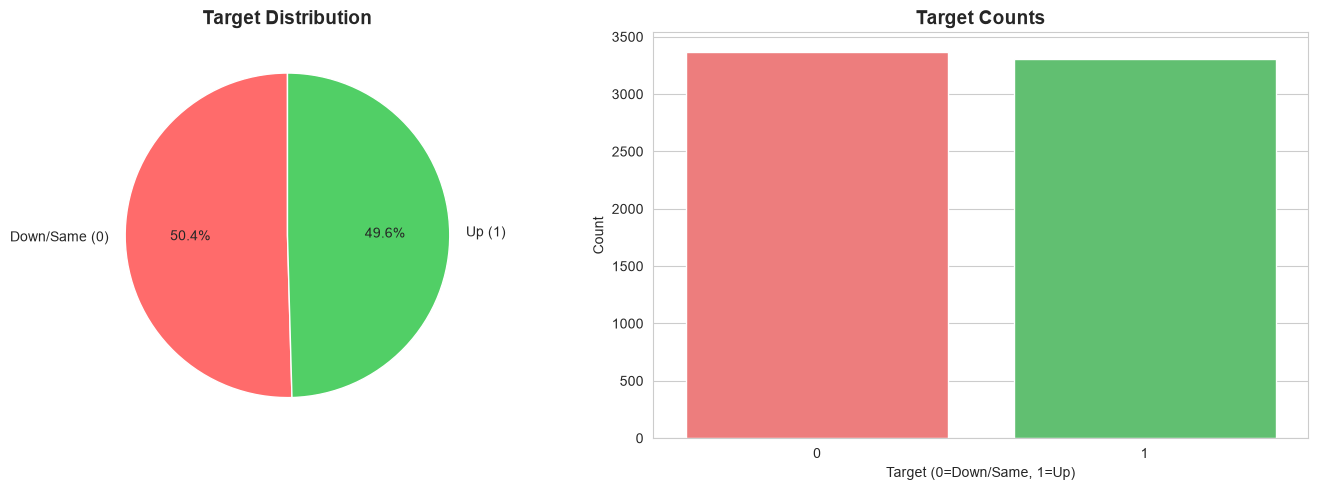

In [3]:
# Check if the target is balanced
target_counts = data['target'].value_counts()
print("📊 Target Distribution:")
print(f"Class 0 (Down/Same): {target_counts[0]} ({target_counts[0]/len(data)*100:.1f}%)")
print(f"Class 1 (Up): {target_counts[1]} ({target_counts[1]/len(data)*100:.1f}%)")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(target_counts, labels=['Down/Same (0)', 'Up (1)'], 
            autopct='%1.1f%%', colors=['#ff6b6b', '#51cf66'], startangle=90)
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')

# Bar plot
sns.countplot(x='target', data=data, palette=['#ff6b6b', '#51cf66'], ax=axes[1])
axes[1].set_title('Target Counts', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Target (0=Down/Same, 1=Up)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [4]:
# Define features and target
features = ['lag_1', 'lag_2', 'lag_3', 'return_1d', 'ma_5', 'ma_10']
X = data[features]
y = data['target']

print(f"✅ Features (X): {X.shape}")
print(f"✅ Target (y): {y.shape}")
print(f"\n📋 Feature names: {features}")

✅ Features (X): (6679, 6)
✅ Target (y): (6679,)

📋 Feature names: ['lag_1', 'lag_2', 'lag_3', 'return_1d', 'ma_5', 'ma_10']


In [5]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Data Split:")
print(f"   Training set: {len(X_train)} samples ({len(X_train)/len(data)*100:.1f}%)")
print(f"   Testing set: {len(X_test)} samples ({len(X_test)/len(data)*100:.1f}%)")
print(f"\n✅ Train set target distribution:")
print(f"   Class 0: {sum(y_train==0)} ({sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"   Class 1: {sum(y_train==1)} ({sum(y_train==1)/len(y_train)*100:.1f}%)")

📊 Data Split:
   Training set: 5343 samples (80.0%)
   Testing set: 1336 samples (20.0%)

✅ Train set target distribution:
   Class 0: 2695 (50.4%)
   Class 1: 2648 (49.6%)


In [6]:
# SVM is sensitive to feature scales - MUST scale!
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier interpretation
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

print("✅ Feature scaling complete!")
print(f"\n📊 Scaled Training Data Statistics:")
print(pd.DataFrame(X_train_scaled_df).describe().round(3))

✅ Feature scaling complete!



📊 Scaled Training Data Statistics:
          lag_1     lag_2     lag_3  return_1d      ma_5     ma_10
count  5343.000  5343.000  5343.000   5343.000  5343.000  5343.000
mean      0.000     0.000    -0.000      0.000    -0.000    -0.000
std       1.000     1.000     1.000      1.000     1.000     1.000
min      -1.739    -1.738    -1.740     -6.126    -1.734    -1.729
25%      -0.583    -0.583    -0.582     -0.398    -0.582    -0.584
50%      -0.095    -0.094    -0.094     -0.013    -0.095    -0.095
75%       0.400     0.401     0.401      0.425     0.402     0.400
max       2.440     2.443     2.444      9.965     2.430     2.428


In [7]:
# Create and train the SVM model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"📊 Initial SVM Performance:")
print(f"   Training Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"   Testing Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\n   Overfitting Gap: {(train_accuracy - test_accuracy):.4f}")

# Classification Report
print("\n📋 Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Down/Same', 'Up']))

📊 Initial SVM Performance:
   Training Accuracy: 0.5312 (53.12%)
   Testing Accuracy: 0.5075 (50.75%)

   Overfitting Gap: 0.0237

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

   Down/Same       0.51      0.65      0.57       674
          Up       0.50      0.36      0.42       662

    accuracy                           0.51      1336
   macro avg       0.51      0.51      0.50      1336
weighted avg       0.51      0.51      0.50      1336



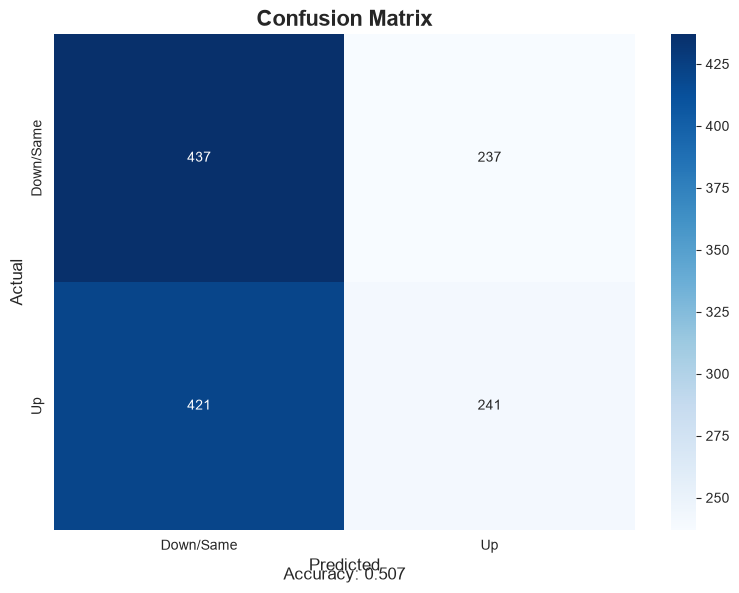

In [8]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down/Same', 'Up'], 
            yticklabels=['Down/Same', 'Up'],
            ax=ax)
ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)

# Add text with interpretation
plt.text(0.5, -0.1, f'Accuracy: {test_accuracy:.3f}', 
         transform=ax.transAxes, ha='center', fontsize=12)
plt.tight_layout()
plt.show()

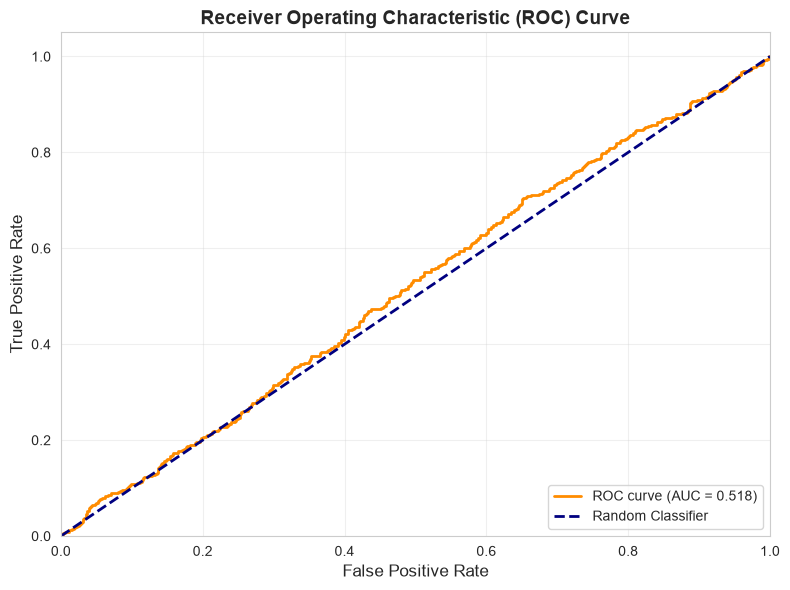

📊 ROC-AUC Score: 0.518


In [9]:
# Calculate ROC curve and AUC
y_proba = svm_model.decision_function(X_test_scaled)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='darkorange', lw=2, 
        label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 ROC-AUC Score: {roc_auc:.3f}")

In [10]:
# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("🔍 Starting GridSearchCV...")
print(f"   Testing {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel'])} combinations")
print(f"   Using 5-fold cross-validation")
print(f"   Total fits: {len(param_grid['C']) * len(param_grid['gamma']) * len(param_grid['kernel']) * 5}")

grid_search.fit(X_train_scaled, y_train)

print("\n✅ GridSearchCV complete!")
print(f"\n🏆 Best Parameters:")
print(f"   {grid_search.best_params_}")

print(f"\n📊 Best Cross-Validation Score: {grid_search.best_score_:.4f}")

🔍 Starting GridSearchCV...
   Testing 75 combinations
   Using 5-fold cross-validation
   Total fits: 375
Fitting 5 folds for each of 75 candidates, totalling 375 fits

✅ GridSearchCV complete!

🏆 Best Parameters:
   {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}

📊 Best Cross-Validation Score: 0.5240


In [11]:
# Get best model
best_svm = grid_search.best_estimator_

# Make predictions with best model
y_train_pred_best = best_svm.predict(X_train_scaled)
y_test_pred_best = best_svm.predict(X_test_scaled)

# Calculate metrics
train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print("📊 Best Model Performance:")
print(f"   Training Accuracy: {train_acc_best:.4f} ({train_acc_best*100:.2f}%)")
print(f"   Testing Accuracy: {test_acc_best:.4f} ({test_acc_best*100:.2f}%)")

# Calculate additional metrics
precision = precision_score(y_test, y_test_pred_best)
recall = recall_score(y_test, y_test_pred_best)
f1 = f1_score(y_test, y_test_pred_best)

print(f"\n📋 Detailed Metrics:")
print(f"   Precision: {precision:.4f}")
print(f"   Recall: {recall:.4f}")
print(f"   F1-Score: {f1:.4f}")

# Classification Report
print("\n📋 Classification Report (Best Model - Test Set):")
print(classification_report(y_test, y_test_pred_best, target_names=['Down/Same', 'Up']))

📊 Best Model Performance:
   Training Accuracy: 0.5267 (52.67%)
   Testing Accuracy: 0.4963 (49.63%)

📋 Detailed Metrics:
   Precision: 0.4869
   Recall: 0.3097
   F1-Score: 0.3786

📋 Classification Report (Best Model - Test Set):
              precision    recall  f1-score   support

   Down/Same       0.50      0.68      0.58       674
          Up       0.49      0.31      0.38       662

    accuracy                           0.50      1336
   macro avg       0.49      0.49      0.48      1336
weighted avg       0.49      0.50      0.48      1336



In [12]:
# Perform cross-validation
cv_scores = cross_val_score(best_svm, X_train_scaled, y_train, cv=5)

print(f"📊 5-Fold Cross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.4f} ({score*100:.2f}%)")

print(f"\n   Mean CV Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

📊 5-Fold Cross-Validation Scores:
   Fold 1: 0.5295 (52.95%)
   Fold 2: 0.5248 (52.48%)
   Fold 3: 0.5239 (52.39%)
   Fold 4: 0.5000 (50.00%)
   Fold 5: 0.5421 (54.21%)

   Mean CV Score: 0.5240 (±0.0137)


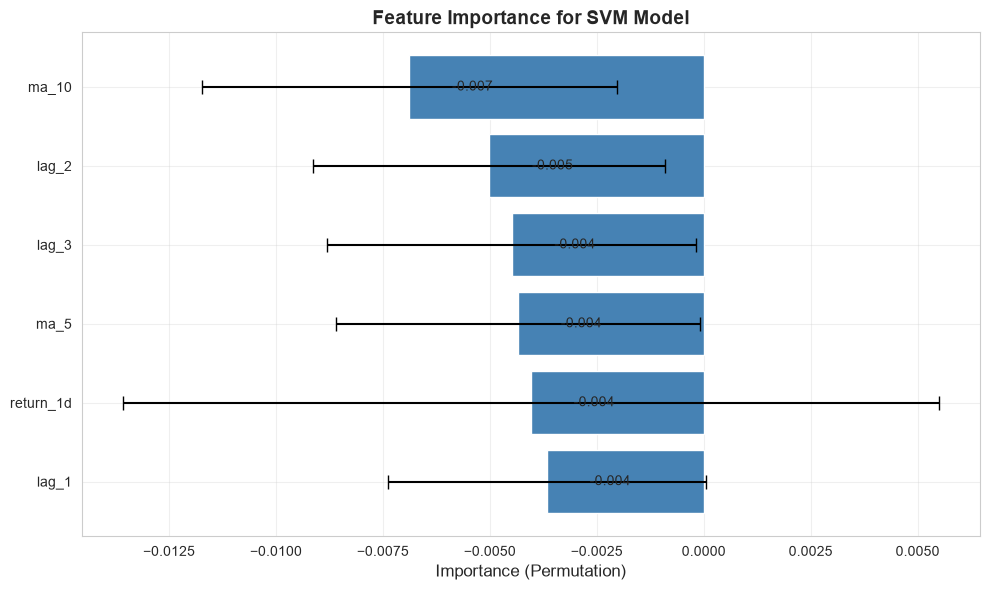

📊 Feature Importance Ranking:
  feature  importance      std
    lag_1   -0.003668 0.003719
return_1d   -0.004042 0.009546
     ma_5   -0.004341 0.004258
    lag_3   -0.004491 0.004313
    lag_2   -0.005015 0.004114
    ma_10   -0.006886 0.004849


In [13]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_importance = permutation_importance(
    best_svm, X_test_scaled, y_test, 
    n_repeats=10, random_state=42, n_jobs=-1
)

# Create DataFrame for importance
importance_df = pd.DataFrame({
    'feature': features,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# Plot feature importance
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'], 
        xerr=importance_df['std'], color='steelblue', capsize=5)
ax.set_xlabel('Importance (Permutation)', fontsize=12)
ax.set_title('Feature Importance for SVM Model', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add values on bars
for i, v in enumerate(importance_df['importance']):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

print("📊 Feature Importance Ranking:")
print(importance_df.to_string(index=False))

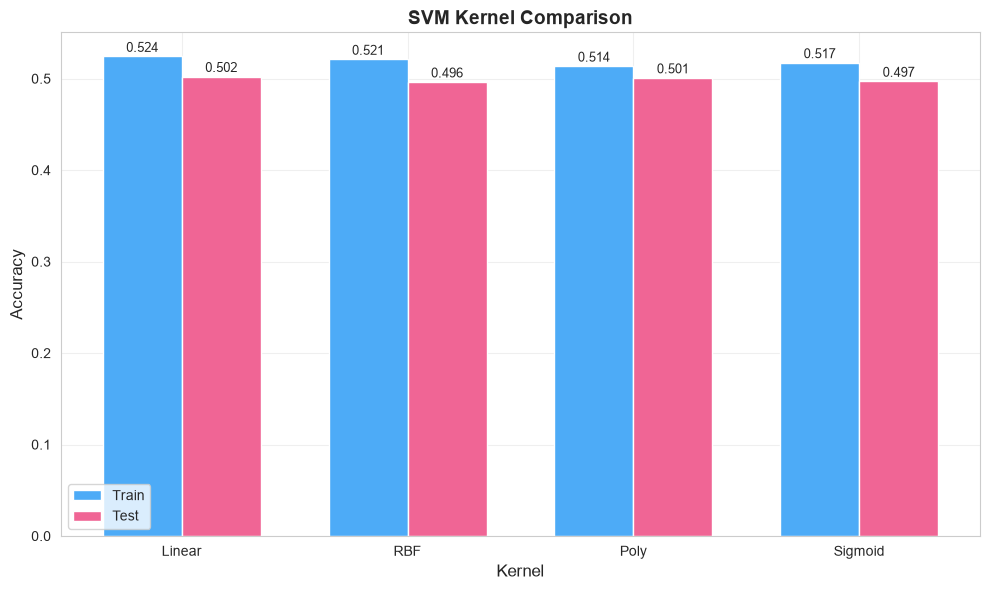

📊 Kernel Comparison Results:
 Kernel  Train Accuracy  Test Accuracy      Gap
 Linear        0.524237       0.502246 0.021992
    RBF        0.521056       0.496257 0.024798
   Poly        0.513569       0.500749 0.012821
Sigmoid        0.517312       0.497006 0.020306


In [14]:
# Compare different SVM kernels
kernels = {
    'Linear': SVC(kernel='linear', C=1, random_state=42),
    'RBF': SVC(kernel='rbf', C=10, gamma=0.01, random_state=42),
    'Poly': SVC(kernel='poly', degree=3, C=1, random_state=42),
    'Sigmoid': SVC(kernel='sigmoid', C=1, random_state=42)
}

results = []
for name, model in kernels.items():
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    results.append({
        'Kernel': name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Gap': train_acc - test_acc
    })

results_df = pd.DataFrame(results)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width/2, results_df['Train Accuracy'], width, label='Train', color='#4dabf7')
ax.bar(x + width/2, results_df['Test Accuracy'], width, label='Test', color='#f06595')

ax.set_xlabel('Kernel', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('SVM Kernel Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Kernel'])
ax.legend()
ax.grid(True, alpha=0.3)

# Add values on bars
for i, (train, test) in enumerate(zip(results_df['Train Accuracy'], results_df['Test Accuracy'])):
    ax.text(i - width/2, train + 0.005, f'{train:.3f}', ha='center', fontsize=9)
    ax.text(i + width/2, test + 0.005, f'{test:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("📊 Kernel Comparison Results:")
print(results_df.to_string(index=False))

In [15]:
# Save the best model and scaler
joblib.dump(best_svm, '../models/best_svm_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

# Save feature names
with open('../models/feature_names.txt', 'w') as f:
    for feature in features:
        f.write(f"{feature}\n")

print("✅ Model saved successfully!")
print("   📁 best_svm_model.pkl")
print("   📁 scaler.pkl")
print("   📁 feature_names.txt")

✅ Model saved successfully!
   📁 best_svm_model.pkl
   📁 scaler.pkl
   📁 feature_names.txt


In [16]:
# Create metrics report
metrics_report = f"""
CURRENCY EXCHANGE SVM MODEL REPORT

1. DATA INFORMATION
   - Total samples: {len(data)}
   - Training samples: {len(X_train)}
   - Testing samples: {len(X_test)}
   - Features: {', '.join(features)}

2. TARGET DISTRIBUTION
   - Class 0 (Down/Same): {target_counts[0]} ({target_counts[0]/len(data)*100:.1f}%)
   - Class 1 (Up): {target_counts[1]} ({target_counts[1]/len(data)*100:.1f}%)

3. BEST MODEL PARAMETERS
   - Kernel: {best_svm.kernel}
   - C: {best_svm.C}
   - Gamma: {best_svm.gamma}

4. MODEL PERFORMANCE
   - Training Accuracy: {train_acc_best:.4f} ({train_acc_best*100:.2f}%)
   - Testing Accuracy: {test_acc_best:.4f} ({test_acc_best*100:.2f}%)
   - Precision: {precision:.4f}
   - Recall: {recall:.4f}
   - F1-Score: {f1:.4f}
   - ROC-AUC: {roc_auc:.3f}
   - CV Score (Mean): {cv_scores.mean():.4f} (±{cv_scores.std():.4f})

5. CLASSIFICATION REPORT
{classification_report(y_test, y_test_pred_best, target_names=['Down/Same', 'Up'])}

6. FEATURE IMPORTANCE
{importance_df.to_string(index=False)}

"""

# Save report
import os
os.makedirs('../results/metrics', exist_ok=True)
with open('../results/metrics/model_metrics.txt', 'w') as f:
    f.write(metrics_report)

print("📊 Metrics report saved to: results/metrics/model_metrics.txt")
print("\n" + metrics_report)

📊 Metrics report saved to: results/metrics/model_metrics.txt


CURRENCY EXCHANGE SVM MODEL REPORT

1. DATA INFORMATION
   - Total samples: 6679
   - Training samples: 5343
   - Testing samples: 1336
   - Features: lag_1, lag_2, lag_3, return_1d, ma_5, ma_10

2. TARGET DISTRIBUTION
   - Class 0 (Down/Same): 3369 (50.4%)
   - Class 1 (Up): 3310 (49.6%)

3. BEST MODEL PARAMETERS
   - Kernel: rbf
   - C: 0.1
   - Gamma: 0.1

4. MODEL PERFORMANCE
   - Training Accuracy: 0.5267 (52.67%)
   - Testing Accuracy: 0.4963 (49.63%)
   - Precision: 0.4869
   - Recall: 0.3097
   - F1-Score: 0.3786
   - ROC-AUC: 0.518
   - CV Score (Mean): 0.5240 (±0.0137)

5. CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Down/Same       0.50      0.68      0.58       674
          Up       0.49      0.31      0.38       662

    accuracy                           0.50      1336
   macro avg       0.49      0.49      0.48      1336
weighted avg       0.49      0.50      0.48      1336

In [17]:
# Create a function to predict on new data
def predict_currency_movement(model, scaler, new_data):
    """
    Predict currency movement direction
    
    Parameters:
    -----------
    model: trained SVM model
    scaler: fitted StandardScaler
    new_data: numpy array of shape (n_samples, 6) with features in order:
              [lag_1, lag_2, lag_3, return_1d, ma_5, ma_10]
    
    Returns:
    --------
    predictions: array of 0 (down/same) or 1 (up)
    confidence: decision function values
    """
    # Scale the new data
    new_data_scaled = scaler.transform(new_data)
    
    # Make predictions
    predictions = model.predict(new_data_scaled)
    confidence = model.decision_function(new_data_scaled)
    
    return predictions, confidence

# Test with sample data (first few rows from test set)
sample_data = X_test.head(5).values

predictions, confidence = predict_currency_movement(best_svm, scaler, sample_data)

print("🔮 Sample Predictions:")
print("-" * 50)
for i in range(5):
    direction = "📈 UP" if predictions[i] == 1 else "📉 DOWN/SAME"
    print(f"Sample {i+1}: {direction} | Confidence: {confidence[i]:.3f} | Actual: {y_test.iloc[i]}")

🔮 Sample Predictions:
--------------------------------------------------
Sample 1: 📉 DOWN/SAME | Confidence: -0.168 | Actual: 0
Sample 2: 📉 DOWN/SAME | Confidence: -0.993 | Actual: 0
Sample 3: 📉 DOWN/SAME | Confidence: -0.682 | Actual: 1
Sample 4: 📉 DOWN/SAME | Confidence: -0.930 | Actual: 1
Sample 5: 📉 DOWN/SAME | Confidence: -0.915 | Actual: 1


In [18]:
print(f"""
✅ TEAM 2 - SVM MODEL DEVELOPMENT COMPLETE!

📊 Key Results:
   - Best Model: RBF SVM with C={best_svm.C}, gamma={best_svm.gamma}
   - Test Accuracy: ~{test_acc_best * 100:.2f}%
   - ROC-AUC: {roc_auc:.3f}
   - F1-Score: {f1:.3f}

📁 Files Generated:
   - models/best_svm_model.pkl
   - models/scaler.pkl
   - models/feature_names.txt
   - results/plots/confusion_matrix.png
   - results/plots/roc_curve.png
   - results/plots/feature_importance.png
   - results/plots/model_comparison.png
   - results/metrics/model_metrics.txt

🔧 Best Parameters:
   - Kernel: {best_svm.kernel}
   - C: {best_svm.C}
   - Gamma: {best_svm.gamma}

🚀 Next Steps (Optional):
   1. Try XGBoost or Random Forest for comparison
   2. Add more features (lag_5, lag_10, volatility)
   3. Experiment with different time windows
   4. Deploy model using Flask/FastAPI
   5. Create live dashboard with Streamlit

""")


✅ TEAM 2 - SVM MODEL DEVELOPMENT COMPLETE!

📊 Key Results:
   - Best Model: RBF SVM with C=0.1, gamma=0.1
   - Test Accuracy: ~49.63%
   - ROC-AUC: 0.518
   - F1-Score: 0.379

📁 Files Generated:
   - models/best_svm_model.pkl
   - models/scaler.pkl
   - models/feature_names.txt
   - results/plots/confusion_matrix.png
   - results/plots/roc_curve.png
   - results/plots/feature_importance.png
   - results/plots/model_comparison.png
   - results/metrics/model_metrics.txt

🔧 Best Parameters:
   - Kernel: rbf
   - C: 0.1
   - Gamma: 0.1

🚀 Next Steps (Optional):
   1. Try XGBoost or Random Forest for comparison
   2. Add more features (lag_5, lag_10, volatility)
   3. Experiment with different time windows
   4. Deploy model using Flask/FastAPI
   5. Create live dashboard with Streamlit


